In [87]:
from datetime import datetime, timezone, timedelta
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

import orbit as om
from constants import EARTH_MU_m3_s2

from orbit import propagate_orbit, cowell_motion
from scipy.integrate import solve_ivp

mu = EARTH_MU_m3_s2
R_EARTH_M = 6_378_136.3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

In [88]:
def make_config(
    x0,
    duration_s,
    method="cowell",
    drag=False,
    J2=False,
    n=1000,
    t0=None,
):
    if t0 is None:
        t0 = datetime(2026, 8, 18, tzinfo=timezone.utc)

    return om.simulation_config(
        t0=t0,
        tf=t0 + timedelta(seconds=float(duration_s)),
        time_steps=int(n),
        propagator_method=method,
        x0=np.asarray(x0, dtype=float),
        drag=drag,
        J2=J2,
    )

def test_propagate_orbit_timesteps(dt_s):
    results = solve_ivp(
        fun=lambda t, x: cowell_motion(x, add_drag=drag, add_J2=J2), 
        t_span =(t0, tf),
        y0=x0,
        t_eval=np.linspace(t_span[0], t_span[1], sampling_time_steps),
        rtol=1e-10, 
        atol=1e-10, 
        method='RK45',
        max_step=dt_s
        )
    return results

def position_error_m(X1, X2):
    return np.linalg.norm(X1[:3] - X2[:3], axis=0)


def velocity_error_m_s(X1, X2):
    return np.linalg.norm(X1[3:] - X2[3:], axis=0)

## Circular test orbit

In [89]:
altitude0_m = 500_000.0
r0_m = R_EARTH_M + altitude0_m

v_circ_m_s = np.sqrt(mu / r0_m)

inclination_deg = 51.6
inc = np.radians(inclination_deg)

x0 = np.array([
    r0_m,
    0.0,
    0.0,
    0.0,
    v_circ_m_s * np.cos(inc),
    v_circ_m_s * np.sin(inc),
])

T_orbit = 2 * np.pi * np.sqrt(r0_m**3 / mu)

print("Initial state [m, m/s]:")
print(x0)
print()
print(f"Radius:         {r0_m/1000:.3f} km")
print(f"Circular speed: {v_circ_m_s:.3f} m/s")
print(f"Inclination:    {inclination_deg:.1f} deg")
print(f"Orbital period: {T_orbit:.2f} s = {T_orbit/60:.2f} min")

duration_s = 10 * T_orbit

Initial state [m, m/s]:
[6.87813630e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00
 4.72856342e+03 5.96596226e+03]

Radius:         6878.136 km
Circular speed: 7612.622 m/s
Inclination:    51.6 deg
Orbital period: 5676.97 s = 94.62 min


## Test 1 - Varying time_steps (n): Time steps from 1 to 600s

Observing the effects of varying the *'time_steps (n)' parameter in the propagate_orbit() function* on the final position error of the satellite.

Configuration:

    - Orbit altitude: 500,000 m 
    - Orbit type: Circular
    - Inclination: 51.6 deg
    - Propagation duration: 10 orbits
    - Propagator method: Cowell
    - J2: Enabled
    - Drag: Disabled
    - Integrator: RK45

    - Varying: time_steps (n)
    - Reference time step: 0.5s
    - Tested time step range: 1 - 600s

In [90]:
time_steps_s = np.linspace(1, 600, 200) # Duration of each time step in seconds
time_steps_n = [int(duration_s / dt) + 1 for dt in time_steps_s] # Number of time steps for each duration

reference_dt_s = 0.5 # Reference time step in seconds
reference_n = int(duration_s / reference_dt_s) + 1 # Number of time steps for the reference duration

reference_config = make_config(
    x0=x0,
    duration_s=duration_s,
    method="cowell",
    drag=False,
    J2=True,
    n=reference_n,
)

test_results = []

for n in time_steps_n:
    test_config = make_config(
        x0=x0,
        duration_s=duration_s,
        method="cowell",
        drag=False,
        J2=True,
        n=n,
    )
    test_results.append(propagate_orbit(test_config))

reference_results = propagate_orbit(reference_config)

time_steps_delta_r = [position_error_m(reference_results[:3, -1], result[:3, -1]) for result in test_results]
final_errors = [errors for errors in time_steps_delta_r]

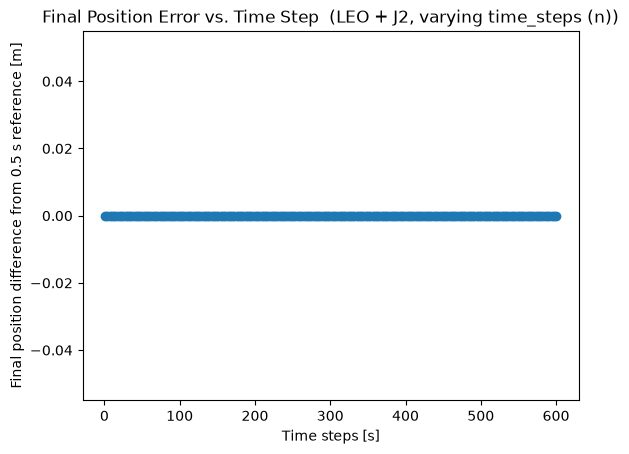

  Time step [s]  Time steps [n]        Final x [m]        Final y [m]        Final z [m]    Final error [m]
            1.0           56770     6841042.185967      174601.372009      691137.706001       0.000000e+00
            4.0           14157     6841042.185967      174601.372009      691137.706001       0.000000e+00
            7.0            8087     6841042.185967      174601.372009      691137.706001       0.000000e+00
           10.0            5660     6841042.185967      174601.372009      691137.706001       0.000000e+00
           13.0            4354     6841042.185967      174601.372009      691137.706001       0.000000e+00
           16.1            3537     6841042.185967      174601.372009      691137.706001       0.000000e+00
           19.1            2979     6841042.185967      174601.372009      691137.706001       0.000000e+00
           22.1            2573     6841042.185967      174601.372009      691137.706001       0.000000e+00
           25.1            2

In [ ]:
plt.plot(time_steps_s, final_errors, marker='o')
plt.title("Final Position Error vs. Time Step (LEO + J2, varying time_steps (n))")
plt.xlabel("Time steps [s]")
plt.ylabel("Final position difference from 0.5 s reference [m]")
# plt.xscale("log")
plt.show()

print(
    f"{'Time step [s]':>15} "
    f"{'Time steps [n]':>15} "
    f"{'Final x [m]':>18} "
    f"{'Final y [m]':>18} "
    f"{'Final z [m]':>18} "
    f"{'Final error [m]':>18}"
)

for dt_s, n, result, error in zip(
    time_steps_s,
    time_steps_n,
    test_results,
    final_errors
):
    final_position = result[:3, -1]

    print(
        f"{dt_s:15.1f} "
        f"{n:15d} "
        f"{final_position[0]:18.6f} "
        f"{final_position[1]:18.6f} "
        f"{final_position[2]:18.6f} "
        f"{error:18.6e}"
    )

Changing the time_steps parameter in the propagate_orbit() function does not seem to have an affect on the final position error of the satellite. This is because time_steps changes the times when results are returned and not the actual integration timestep. To vary the integration timestep we can use the max_step parameter in the solve_ivp() function which determines the maximum size of the time steps that the integrator is allowed to take.

## Test 2 - Changing max_step: Timesteps from 1 to 600s

Observing the effects of varying the *'max_step' parameter in the solve_ivp() function* on the final position error of the satellite.

Configuration:

    - Orbit altitude: 500,000 m 
    - Orbit type: Circular
    - Inclination: 51.6 deg
    - Propagation duration: 10 orbits
    - Propagator method: Cowell
    - J2: Enabled
    - Drag: Disabled
    - Integrator: RK45
    
    - Varying: max_step
    - Reference time step: 0.5s
    - Tested time step range: 1 - 600s

In [92]:
t0 = 0.0
tf = 10 * T_orbit
t_span = (t0, tf)
sampling_time_steps = 1000

drag = False
J2 = True

In [93]:
reference = test_propagate_orbit_timesteps(0.5)

time_steps = np.linspace(1, 600, 200)

results = [test_propagate_orbit_timesteps(step) for step in time_steps]

max_step_delta_r = [position_error_m(reference.y, result.y) for result in results]
final_errors = [errors[-1] for errors in max_step_delta_r]


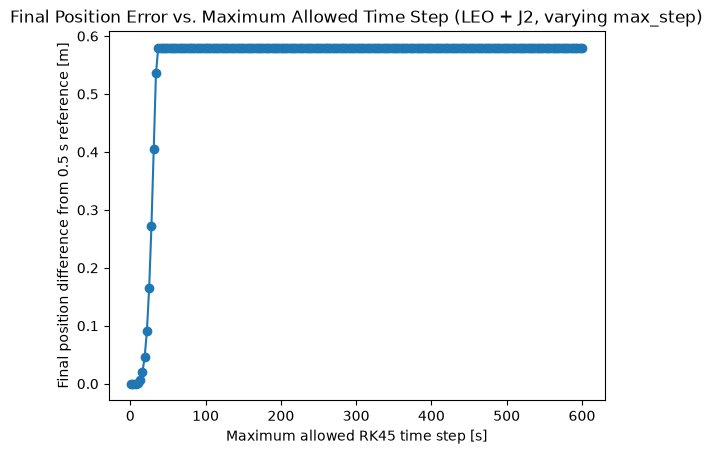

In [99]:
plt.plot(time_steps, final_errors, marker='o')
plt.title("Final Position Error vs. Maximum Allowed Time Step (LEO + J2, varying max_step)")
plt.xlabel("Maximum allowed RK45 time step [s]")
plt.ylabel("Final position difference from 0.5 s reference [m]")
# plt.xscale("log")
plt.show()

We can see that when we change max_step, the errors in the final position of the satellite after 10 orbits increase rapidly between  1 - 40 second time steps and then plateaus after ~40 second maximum time steps. This is likely due to the integrator continuously selecting time steps that are around 40 seconds even when the maximum allowed time step is much larger. 

## Test 3 - Where is the Plateau?

In [ ]:
# Helper function for the propagator that removes t_eval to see what the actual time steps are when we set a maximum step size.
def run_timestep(dt_s):
    results = solve_ivp(
        fun=lambda t, x: cowell_motion(x, add_drag=drag, add_J2=J2), 
        t_span =(t0, tf),
        y0=x0,
        rtol=1e-10, 
        atol=1e-10, 
        method='RK45',
        max_step=dt_s
        )
    return results


max_steps = np.linspace(1, 600, 200)

largest_actual_steps = []

for max_step in max_steps:
    result = run_timestep(max_step)

    actual_steps = np.diff(result.t)

    largest_actual_steps.append(
        np.max(actual_steps)
    )

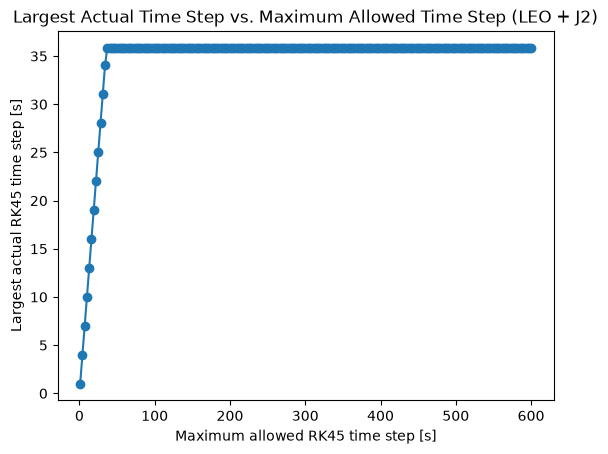

In [104]:
plt.plot(
    max_steps,
    largest_actual_steps,
    marker="o"
)
plt.title("Largest Actual Time Step vs. Maximum Allowed Time Step (LEO + J2)")
plt.xlabel("Maximum allowed RK45 time step [s]")
plt.ylabel("Largest actual RK45 time step [s]")

# plt.xscale("log")
# plt.yscale("log")

plt.show()

In [97]:
print(
    f"{'Allowed max time step [s]':>20} "
    f"{'Largest actual time step [s]':>22} "
    f"{'Final error [m]':>18}"
)

for max_step, actual_step, error in zip(
    max_steps,
    largest_actual_steps,
    final_errors
):
    print(
        f"{max_step:20.1f} "
        f"{actual_step:22.3f} "
        f"{error:18.6f}"
    )

Allowed max time step [s] Largest actual time step [s]    Final error [m]
                 1.0                  1.000           0.000007
                 4.0                  4.010           0.000018
                 7.0                  7.020           0.000318
                10.0                 10.030           0.001893
                13.0                 13.040           0.006999
                16.1                 16.050           0.019633
                19.1                 19.060           0.045464
                22.1                 22.070           0.091364
                25.1                 25.080           0.165749
                28.1                 28.090           0.272130
                31.1                 31.101           0.404491
                34.1                 34.111           0.535981
                37.1                 35.871           0.579950
                40.1                 35.871           0.579950
                43.1                 35.871 

We can see that the time steps used by the integrator remains around 35 seconds even when larger time steps are allowed.

## Test 4 - Position Error Accumulation Over Time for Different Maximum Time Steps

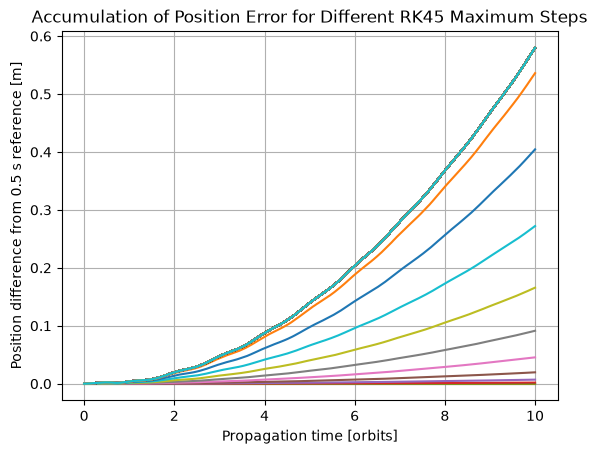

In [106]:
time_in_orbits = reference.t / T_orbit

for step, errors in zip(time_steps, max_step_delta_r):
    plt.plot(
        time_in_orbits,
        errors,
        label=f"{step} s"
    )

plt.xlabel("Propagation time [orbits]")
plt.ylabel("Position difference from 0.5 s reference [m]")
plt.title("Accumulation of Position Error for Different RK45 Maximum Steps")
# plt.legend()
plt.grid()
plt.show()